In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.16.1


In [2]:
import numpy as np

print("NumPy version:", np.__version__)


NumPy version: 1.26.4


In [3]:
import matplotlib.pylab as plt
print("Matplotlib version:", plt.__version__)

Matplotlib version: 1.26.4


In [4]:
### Prepare training  validation & test  dataset
import os
folder = '/kaggle/input/rice-diseases'
data_dir = os.path.join(os.path.dirname(folder), '/kaggle/input/rice-diseases')
train_dir = os.path.join(data_dir, 'train')
validation_dir = os.path.join(data_dir, 'validation')
test_dir = os.path.join(data_dir, 'test')




In [5]:
import time
import os
from os.path import exists

def count(dir, counter=0):
    "returns number of files in dir and subdirs"
    for pack in os.walk(dir):
        for f in pack[2]:
            counter += 1
    return dir + " : " + str(counter) + "files"


In [6]:
print('total images for training :', count(train_dir))
print('total images for validation :', count(validation_dir))
print('total images for test :', count(test_dir))



total images for training : /kaggle/input/rice-diseases/train : 1338files
total images for validation : /kaggle/input/rice-diseases/validation : 384files
total images for test : /kaggle/input/rice-diseases/test : 192files


In [7]:
import os

def create_label_mapping(directory):
    label_mapping = {}
    for idx, label in enumerate(os.listdir(directory)):
        label_mapping[label] = idx
    return label_mapping

# Assuming 'train_dir', 'validation_dir', and 'test_dir' are already defined
train_label_mapping = create_label_mapping(train_dir)
validation_label_mapping = create_label_mapping(validation_dir)
test_label_mapping = create_label_mapping(test_dir)

print('Label mapping for training:', train_label_mapping)
print('Label mapping for validation:', validation_label_mapping)
print('Label mapping for test:', test_label_mapping)


Label mapping for training: {'Leaf Blast': 0, 'Brown spot': 1, 'Bacterial leaf blight': 2}
Label mapping for validation: {'Leaf Blast': 0, 'Brown spot': 1, 'Bacterial leaf blight': 2}
Label mapping for test: {'Leaf Blast': 0, 'Brown spot': 1, 'Bacterial leaf blight': 2}


In [8]:
import os

def count_images_per_class(directory):
    """Counts the number of images per class in the specified directory."""
    class_counts = {}
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            class_counts[class_name] = len(os.listdir(class_path))
    return class_counts

# Count the number of images in each class for training, validation, and test sets
train_class_counts = count_images_per_class(train_dir)
validation_class_counts = count_images_per_class(validation_dir)
test_class_counts = count_images_per_class(test_dir)

# Print the counts for training, validation, and test sets
print("Image counts per class for training:")
for class_name, count in train_class_counts.items():
    print(f"{class_name}: {count} images")

print("\nImage counts per class for validation:")
for class_name, count in validation_class_counts.items():
    print(f"{class_name}: {count} images")

print("\nImage counts per class for test:")
for class_name, count in test_class_counts.items():
    print(f"{class_name}: {count} images")

# Optional: Check if the dataset is balanced
def is_balanced(class_counts):
    counts = list(class_counts.values())
    return max(counts) - min(counts) <= (0.1 * max(counts))

print("\nIs the training dataset balanced?", is_balanced(train_class_counts))
print("Is the validation dataset balanced?", is_balanced(validation_class_counts))
print("Is the test dataset balanced?", is_balanced(test_class_counts))


Image counts per class for training:
Leaf Blast: 446 images
Brown spot: 446 images
Bacterial leaf blight: 446 images

Image counts per class for validation:
Leaf Blast: 128 images
Brown spot: 128 images
Bacterial leaf blight: 128 images

Image counts per class for test:
Leaf Blast: 64 images
Brown spot: 64 images
Bacterial leaf blight: 64 images

Is the training dataset balanced? True
Is the validation dataset balanced? True
Is the test dataset balanced? True


In [10]:
# =========================
# CELL 1: Imports & Setup
# =========================
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetV2L
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import ModelCheckpoint, Callback

# =========================
# CELL 2: Directories & Parameters
# =========================
base_folder = '/kaggle/input/rice-diseases'
train_dir = os.path.join(base_folder, 'train')
validation_dir = os.path.join(base_folder, 'validation')
test_dir = os.path.join(base_folder, 'test')

# Hyperparameters
img_width, img_height = 384, 384
batch_size = 32
num_classes = 3
lr = 0.001
epochs = 30

# =========================
# CELL 3: Callbacks
# =========================
class TimeHistory(Callback):

    def on_train_begin(self, logs=None):
        self.times = []

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        self.times.append(time.time() - self.epoch_start_time)

time_callback = TimeHistory()

total_start_time = time.time()

checkpoint_cb = ModelCheckpoint(
    'best_efficientnetv2.keras',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)

# =========================
# CELL 4: Data Generators
# =========================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=20,
    zoom_range=0.2
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

validation_generator = val_test_datagen.flow_from_directory(
    validation_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# =========================
# CELL 5: Model Setup
# =========================
base_model = EfficientNetV2L(
    weights='imagenet',
    include_top=False,
    input_shape=(img_width, img_height, 3)
)

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=SGD(learning_rate=lr, momentum=0.9, nesterov=True),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# =========================
# CELL 6: Train Model (FIXED)
# =========================
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=validation_generator,
    callbacks=[time_callback, checkpoint_cb],
    verbose=1
)

# =========================
# Training Time
# =========================
total_training_time = time.time() - total_start_time
average_epoch_time = total_training_time / epochs

print("Total Training Time:", total_training_time)
print("Average Epoch Time:", average_epoch_time)

Found 1338 images belonging to 3 classes.
Found 384 images belonging to 3 classes.
Found 192 images belonging to 3 classes.


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 384, 384,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 384, 384,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 192, 192,  │        864 │ rescaling_1[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 192, 192,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 192, 192,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 192, 192,  │      9,216 │ stem_activation[… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 192, 192,  │        128 │ block1a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 192, 192,  │          0 │ block1a_project_… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_add (Add)   │ (None, 192, 192,  │          0 │ block1a_project_… │
│                     │ 32)               │            │ stem_activation[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_co… │ (None, 192, 192,  │      9,216 │ block1a_add[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_bn  │ (None, 192, 192,  │        128 │ block1b_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_ac… │ (None, 192, 192,  │          0 │ block1b_project_… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_drop        │ (None, 192, 192,  │          0 │ block1b_project_… │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_add (Add)   │ (None, 192, 192,  │          0 │ block1b_drop[0][… │
│                     │ 32)               │            │ block1a_add[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1c_project_co… │ (None, 192, 192,  │      9,216 │ block1b_add[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1c_project_bn  │ (None, 192, 192,  │        128 │ block1c_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1c_project_ac… │ (None, 192, 192,  │          0 │ block1c_project_

 Total params: 117,750,691 (449.18 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 117,746,848 (449.17 MB)

Epoch 1/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 370s 5s/step - accuracy: 0.3273 - loss: 1.1018 - val_accuracy: 0.3333 - val_loss: 1.0997
Epoch 2/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.3240 - loss: 1.1000 - val_accuracy: 0.3438 - val_loss: 1.0988
Epoch 3/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.3280 - loss: 1.0996 - val_accuracy: 0.3620 - val_loss: 1.0982
Epoch 4/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.3358 - loss: 1.0997 - val_accuracy: 0.3646 - val_loss: 1.0978
Epoch 5/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.3337 - loss: 1.0979 - val_accuracy: 0.3672 - val_loss: 1.0975
Epoch 6/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.3495 - loss: 1.0976 - val_accuracy: 0.3516 - val_loss: 1.0971
Epoch 7/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.3275 - loss: 1.0978 - val_accuracy: 0.3620 - val_loss: 1.0968
Epoch 8/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.3218 - loss: 1.0988 - val_accuracy: 0.3672 - val_loss

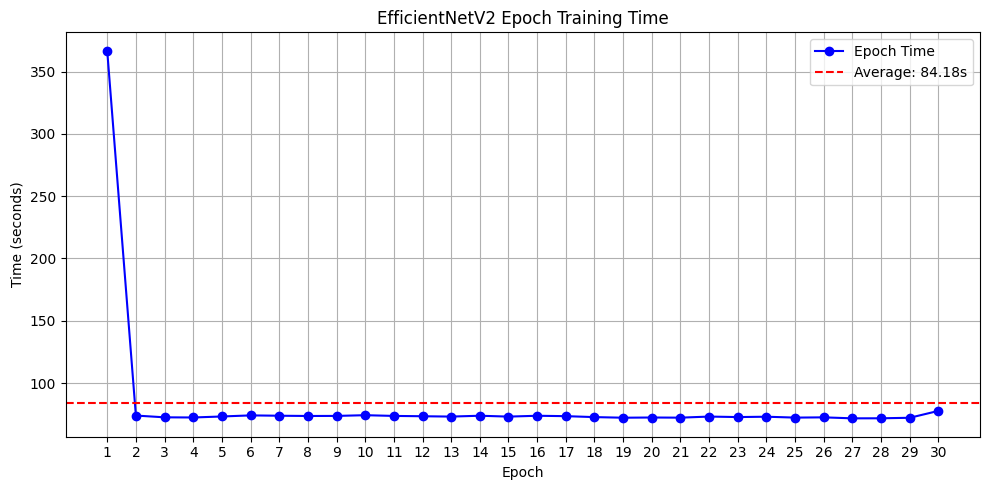

Total Training Time: 42.09 minutes
Average Epoch Time: 84.18 seconds


In [11]:
# =========================
# CELL 7: Epoch Time Plot (Saved at 500 dpi)
# =========================
plt.figure(figsize=(10,5))
plt.plot(range(1, epochs+1), time_callback.times, 'b-o', label='Epoch Time')
plt.axhline(
    y=average_epoch_time,
    color='r',
    linestyle='--',
    label=f'Average: {average_epoch_time:.2f}s'
)

plt.xlabel('Epoch')
plt.ylabel('Time (seconds)')
plt.title('EfficientNetV2 Epoch Training Time')

plt.xticks(range(1, epochs+1))
plt.legend()
plt.grid(True)
plt.tight_layout()

# =========================
# Save figure at 500 dpi
# =========================
plt.savefig("EfficientNetV2_Epoch_Training_Time.png", dpi=500, bbox_inches='tight')

plt.show()

print(f"Total Training Time: {total_training_time/60:.2f} minutes")
print(f"Average Epoch Time: {average_epoch_time:.2f} seconds")

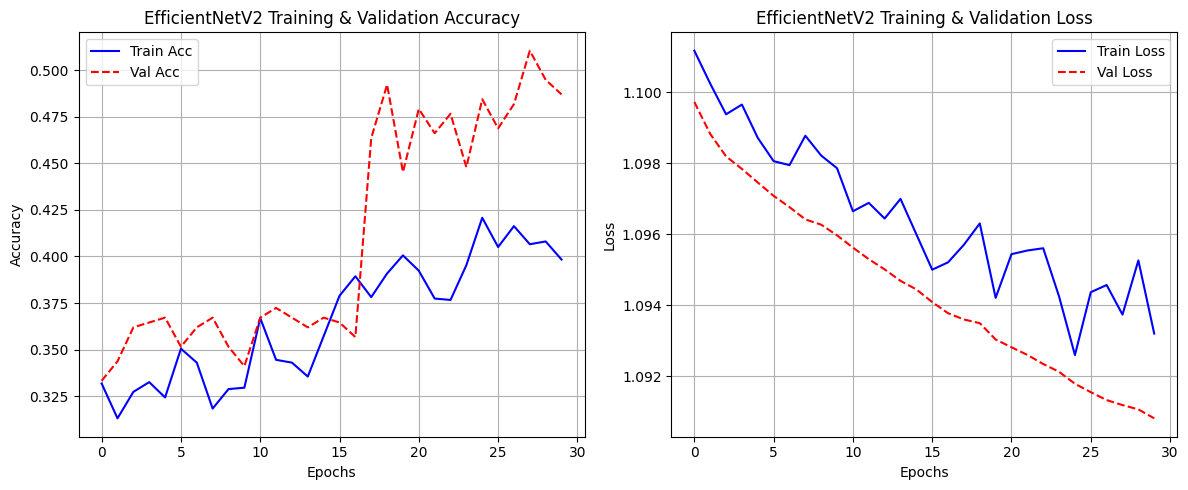

In [12]:
# =========================
# CELL 8: Accuracy & Loss Plot (Saved at 500 dpi)
# =========================
plt.figure(figsize=(12,5))

# Accuracy Plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], 'b-', label='Train Acc')
plt.plot(history.history['val_accuracy'], 'r--', label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('EfficientNetV2 Training & Validation Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], 'b-', label='Train Loss')
plt.plot(history.history['val_loss'], 'r--', label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('EfficientNetV2 Training & Validation Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()

# =========================
# Save figure at 500 dpi
# =========================
plt.savefig("EfficientNetV2_Accuracy_Loss.png", dpi=500, bbox_inches='tight')

plt.show()

12/12 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step


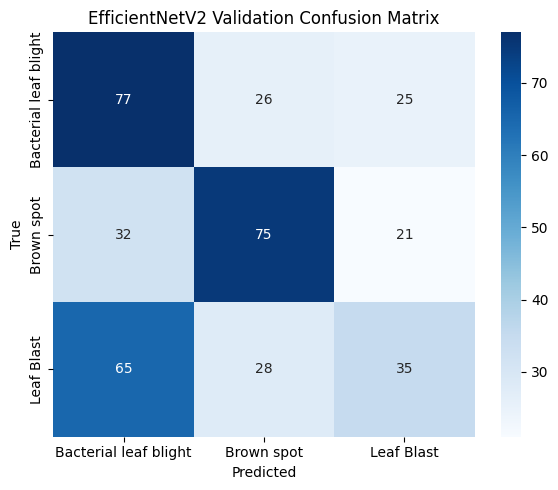

                       precision    recall  f1-score   support

Bacterial leaf blight       0.44      0.60      0.51       128
           Brown spot       0.58      0.59      0.58       128
           Leaf Blast       0.43      0.27      0.33       128

             accuracy                           0.49       384
            macro avg       0.49      0.49      0.48       384
         weighted avg       0.49      0.49      0.48       384



In [13]:
# =========================
# CELL 9: Confusion Matrix (Validation) - Save at 500 dpi
# =========================
validation_generator.reset()
val_preds = model.predict(validation_generator, steps=len(validation_generator), verbose=1)
val_pred_labels = np.argmax(val_preds, axis=1)
val_true_labels = validation_generator.classes

cm_val = confusion_matrix(val_true_labels, val_pred_labels)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_val,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=validation_generator.class_indices.keys(),
    yticklabels=validation_generator.class_indices.keys()
)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('EfficientNetV2 Validation Confusion Matrix')
plt.tight_layout()

# =========================
# Save figure at 500 dpi
# =========================
plt.savefig("EfficientNetV2_Confusion_Matrix_Validation.png", dpi=500, bbox_inches='tight')

plt.show()

# =========================
# Classification Report
# =========================
print(classification_report(
    val_true_labels,
    val_pred_labels,
    target_names=list(validation_generator.class_indices.keys())
))

/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 913ms/step


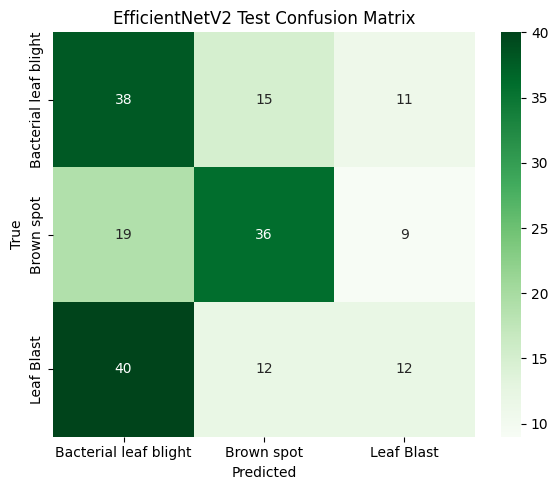

                       precision    recall  f1-score   support

Bacterial leaf blight       0.39      0.59      0.47        64
           Brown spot       0.57      0.56      0.57        64
           Leaf Blast       0.38      0.19      0.25        64

             accuracy                           0.45       192
            macro avg       0.45      0.45      0.43       192
         weighted avg       0.45      0.45      0.43       192



In [14]:
# =========================
# CELL 10: Confusion Matrix (Test) - Save at 500 dpi
# =========================
test_generator.reset()
test_preds = model.predict(test_generator, steps=len(test_generator), verbose=1)
test_pred_labels = np.argmax(test_preds, axis=1)
test_true_labels = test_generator.classes

cm_test = confusion_matrix(test_true_labels, test_pred_labels)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_test,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=test_generator.class_indices.keys(),
    yticklabels=test_generator.class_indices.keys()
)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('EfficientNetV2 Test Confusion Matrix')
plt.tight_layout()

# =========================
# Save figure at 500 dpi
# =========================
plt.savefig("EfficientNetV2_Confusion_Matrix_Test.png", dpi=500, bbox_inches='tight')

plt.show()

# =========================
# Classification Report
# =========================
print(classification_report(
    test_true_labels,
    test_pred_labels,
    target_names=list(test_generator.class_indices.keys())
))

6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 935ms/step


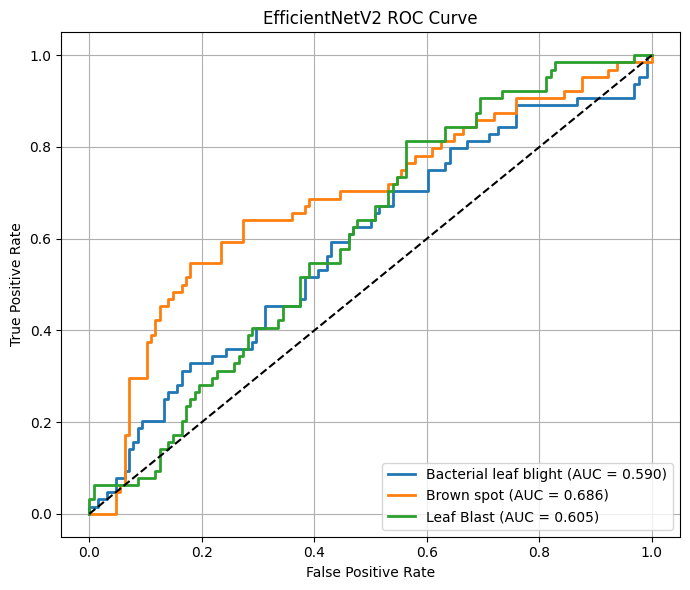

In [15]:
# =========================
# CELL 11: ROC Curve (Test Set) - Save at 500 dpi
# =========================
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# True labels
y_true = test_generator.classes

# Predicted probabilities
y_score = model.predict(test_generator, verbose=1)

# Binarize labels
n_classes = num_classes
y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# =========================
# Plot ROC Curves
# =========================
plt.figure(figsize=(7,6))

class_names = list(test_generator.class_indices.keys())

for i in range(n_classes):
    plt.plot(
        fpr[i],
        tpr[i],
        lw=2,
        label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})'
    )

# Random guess line
plt.plot([0,1], [0,1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('EfficientNetV2 ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()

# =========================
# Save ROC figure
# =========================
plt.savefig("EfficientNetV2_ROC_Curve.png", dpi=500, bbox_inches='tight')

plt.show()

In [16]:
import cv2
import numpy as np
import os
import random
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
import shutil
from pathlib import Path

# =========================
# CONFIG
# =========================
IMAGE_SIZE = (384, 384)

test_dir = '/kaggle/input/rice-diseases/test'
RESULT_DIR = '/kaggle/working/results'
ZIP_NAME = '/kaggle/working/result'

os.makedirs(RESULT_DIR, exist_ok=True)

# =========================
# Load Model
# =========================
model = load_model('/kaggle/working/best_efficientnetv2.keras')

classes = ['Bacterial leaf blight', 'Brown spot', 'Leaf Blast']

# =========================
# Data Generator
# =========================
datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=IMAGE_SIZE,
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# =========================
# Load Image
# =========================
def load_image(filename):
    full_path = os.path.join(test_dir, filename)
    
    img = cv2.imread(full_path)
    
    if img is None:
        raise FileNotFoundError(f"Could not read image at path: {full_path}")
    
    img_resized = cv2.resize(img, IMAGE_SIZE)
    img_preprocessed = preprocess_input(img_resized.astype(np.float32))
    
    return img_resized, img_preprocessed


# =========================
# Predict
# =========================
def predict(image):
    
    probs = model.predict(np.asarray([image]), verbose=0)[0]
    idx = np.argmax(probs)
    
    return classes[idx], probs[idx]


# =========================
# GrabCut Segmentation
# =========================
def apply_grabcut(image):

    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    mask = np.zeros(rgb.shape[:2], np.uint8)

    bgd_model = np.zeros((1,65), np.float64)
    fgd_model = np.zeros((1,65), np.float64)

    h, w = rgb.shape[:2]

    rect = (10,10,w-20,h-20)

    cv2.grabCut(rgb, mask, rect, bgd_model, fgd_model, 5, cv2.GC_INIT_WITH_RECT)

    foreground_mask = np.where(
        (mask==cv2.GC_FGD) | (mask==cv2.GC_PR_FGD),
        1,0
    ).astype('uint8')

    return foreground_mask, rgb


# =========================
# Disease Segmentation
# =========================
def visualize_segmentation(foreground_mask, rgb):

    output = rgb.copy()

    # Leaf Boundary
    leaf_contours,_ = cv2.findContours(
        foreground_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    cv2.drawContours(output, leaf_contours, -1, (255,0,0), 3)

    segmented = rgb.copy()
    segmented[foreground_mask==0] = 0

    hsv = cv2.cvtColor(segmented, cv2.COLOR_RGB2HSV)

    # Yellow/Brown lesions
    lower1 = np.array([10,40,40])
    upper1 = np.array([35,255,255])
    mask1 = cv2.inRange(hsv, lower1, upper1)

    # White lesions
    lower2 = np.array([0,0,180])
    upper2 = np.array([180,60,255])
    mask2 = cv2.inRange(hsv, lower2, upper2)

    disease_mask = cv2.bitwise_or(mask1, mask2)

    kernel = np.ones((5,5), np.uint8)

    disease_mask = cv2.morphologyEx(disease_mask, cv2.MORPH_CLOSE, kernel)
    disease_mask = cv2.morphologyEx(disease_mask, cv2.MORPH_OPEN, kernel)

    disease_contours,_ = cv2.findContours(
        disease_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    overlay = output.copy()

    alpha = 0.4

    for cnt in disease_contours:

        if cv2.contourArea(cnt) > 500:
            cv2.drawContours(overlay, [cnt], -1, (0,255,255), -1)

    final_output = cv2.addWeighted(overlay, alpha, output, 1-alpha, 0)

    return final_output


# =========================
# Generate & Save Results
# =========================
print("🔄 Processing images and saving results...")

for i, filename in enumerate(random.sample(test_generator.filenames, 50), 1):

    print(f"\nProcessing {i}/50: {filename}")
    print(f"Source: {os.path.split(filename)[0]} | File: {filename}")

    try:

        original_img, img_preprocessed = load_image(filename)

        pred_class, conf = predict(img_preprocessed)

        foreground_mask, rgb = apply_grabcut(original_img)

        final_output = visualize_segmentation(foreground_mask, rgb)

        plt.figure(figsize=(12,6))

        plt.subplot(1,2,1)
        plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
        plt.title(f"Original Image\nSource: {os.path.split(filename)[0]}")
        plt.axis("off")

        plt.subplot(1,2,2)
        plt.imshow(final_output)
        plt.title(f"EfficientNetV2 Model\nClass: {pred_class}\nConfidence: {conf:.2f}")
        plt.axis("off")

        plt.tight_layout()

        save_path = os.path.join(RESULT_DIR, f"result_{i}.png")

        plt.savefig(save_path, dpi=500, bbox_inches='tight')
        plt.close()

        print(f"  ✅ Saved: result_{i}.png | Prediction: {pred_class} ({conf:.2f})")

    except Exception as e:

        print(f"  ❌ Error: {e}")
        continue


# =========================
# ZIP Results
# =========================
print("\n📦 Creating ZIP archive...")

shutil.make_archive(ZIP_NAME, 'zip', RESULT_DIR)

print("\n"+"="*50)
print("✅ PROCESSING COMPLETE!")
print("="*50)
print(f"📍 Results saved in: {RESULT_DIR}/")
print(f"📍 50 high-resolution images saved at 500 DPI")
print(f"📍 ZIP file created: {ZIP_NAME}.zip")
print("📥 Ready for download!")
print("="*50)

Found 192 images belonging to 3 classes.
🔄 Processing images and saving results...

Processing 1/50: Leaf Blast/Leaf Blast_original_BLAST2_018.jpg_eb85cd75-6ea1-4a18-9888-d3f96e38306b.PNG
Source: Leaf Blast | File: Leaf Blast/Leaf Blast_original_BLAST2_018.jpg_eb85cd75-6ea1-4a18-9888-d3f96e38306b.PNG
  ✅ Saved: result_1.png | Prediction: Brown spot (0.45)

Processing 2/50: Bacterial leaf blight/Bacterial leaf blight_original_BACTERAILBLIGHT3_030.jpg_5634c004-eedc-4371-a673-158a681a6cff.PNG
Source: Bacterial leaf blight | File: Bacterial leaf blight/Bacterial leaf blight_original_BACTERAILBLIGHT3_030.jpg_5634c004-eedc-4371-a673-158a681a6cff.PNG
  ✅ Saved: result_2.png | Prediction: Brown spot (0.42)

Processing 3/50: Bacterial leaf blight/Bacterial leaf blight_original_BACTERIALBLIGHT1_125.jpg_422c4af9-6681-4c5d-ac4f-091ea4620da4.PNG
Source: Bacterial leaf blight | File: Bacterial leaf blight/Bacterial leaf blight_original_BACTERIALBLIGHT1_125.jpg_422c4af9-6681-4c5d-ac4f-091ea4620da4.PN